In [1]:
import pandas as pd
from datetime import date, timedelta
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import requests

In [2]:
end_date = date.today()
start_date = end_date - timedelta(days=5)

dados = yf.download("PETR4.SA", start=start_date, end=end_date)

S0 = dados["Close"].dropna().iloc[-1]
S0 = float(S0)

moneyness_K = 1.15
moneyness_H = 1.30

K = S0 * moneyness_K
H = S0 * moneyness_H

[*********************100%***********************]  1 of 1 completed
C:\Users\lucab\AppData\Local\Temp\ipykernel_11880\4250254320.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(S0)


In [3]:
def listar_opcoes(ativo_obj, vencimento):
    url = (
        f'https://opcoes.net.br/listaopcoes/completa?'
        f'idAcao={ativo_obj}&listarVencimentos=false&cotacoes=true&vencimentos={vencimento}'
    )

    r = requests.get(url).json()

    l = [
        [
            ativo_obj,
            vencimento,
            i[0].split('_')[0],
            i[2],
            i[3],
            i[5],
            i[8]
        ]
        for i in r['data']['cotacoesOpcoes']
    ]

    return pd.DataFrame(
        l,
        columns=['ativo_obj', 'vencimento', 'ativo', 'tipo', 'modelo', 'strike', 'preco']
    )


def listar_opcoes_365_dias(ativo_obj):
    hoje = pd.Timestamp.today().normalize()

    dfs = []

    for i in range(365):
        data = hoje + pd.Timedelta(days=i)
        vencimento = data.strftime('%Y-%m-%d')

        try:
            df = listar_opcoes(ativo_obj, vencimento)

            if not df.empty:
                df['dias_uteis_vencimento'] = df['vencimento'].apply(
                    lambda x: len(pd.bdate_range(start=hoje, end=x)) - 1
                )

                dfs.append(df)

        except Exception as e:
            print(f"Erro no vencimento {vencimento}: {e}")

    if dfs:
        return pd.concat(dfs, ignore_index=True)

    return pd.DataFrame(
        columns=[
            'ativo_obj',
            'vencimento',
            'ativo',
            'tipo',
            'modelo',
            'strike',
            'preco',
            'dias_uteis_vencimento'
        ]
    )

In [4]:
ATIVO = listar_opcoes_365_dias('PETR4').dropna()
ATIVO = ATIVO[ATIVO["tipo"] == 'CALL']

C:\Users\lucab\AppData\Local\Temp\ipykernel_11880\584379992.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dfs, ignore_index=True)


In [5]:
from io import StringIO

ANBIMA_URL = "https://www.anbima.com.br/informacoes/est-termo/CZ-down.asp"

HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://www.anbima.com.br/",
}


def to_float_br(x):
    if isinstance(x, str):
        x = x.replace(".", "").replace(",", ".")
    return float(x)


def buscar_curva_parametrica_anbima(data_ref=None, max_du=2520):
    if data_ref is None:
        hoje = date.today()

        if hoje.weekday() == 0:
            data_ref = hoje - timedelta(days=3)
        elif hoje.weekday() == 6:
            data_ref = hoje - timedelta(days=2)
        else:
            data_ref = hoje - timedelta(days=1)

        data_ref = data_ref.strftime("%d/%m/%Y")

    params = {
        "Tipo": "ETTJPreFixado",
        "DataRef": data_ref,
        "Instrucao": "None",
    }

    resp = requests.get(
        ANBIMA_URL,
        params=params,
        headers=HEADERS,
        timeout=15
    )

    resp.raise_for_status()

    raw = resp.content.decode("latin-1")

    lines = [
        l for l in raw.splitlines()
        if l.strip() and not l.startswith("(*")
    ]

    sep = ";" if ";" in lines[0] else ","

    df_param = pd.read_csv(
        StringIO("\n".join(lines)),
        sep=sep,
        decimal=",",
        thousands="."
    )

    df_param.columns = [c.strip() for c in df_param.columns]

    row = df_param.iloc[0]

    beta1 = to_float_br(row["Beta 1"])
    beta2 = to_float_br(row["Beta 2"])
    beta3 = to_float_br(row["Beta 3"])
    beta4 = to_float_br(row["Beta 4"])
    lambda1 = to_float_br(row["Lambda 1"])
    lambda2 = to_float_br(row["Lambda 2"])

    curva = []

    for du in range(1, max_du + 1):
        t = du / 252

        termo1 = (1 - np.exp(-lambda1 * t)) / (lambda1 * t)
        termo2 = termo1 - np.exp(-lambda1 * t)
        termo3 = ((1 - np.exp(-lambda2 * t)) / (lambda2 * t)) - np.exp(-lambda2 * t)

        taxa_aa_decimal = (
            beta1
            + beta2 * termo1
            + beta3 * termo2
            + beta4 * termo3
        )

        curva.append([du, t, taxa_aa_decimal])

    return pd.DataFrame(
        curva,
        columns=["dias_uteis_vencimento", "T", "r"]
    )


curva_juros = buscar_curva_parametrica_anbima()

ATIVO["dias_uteis_vencimento"] = pd.to_numeric(
    ATIVO["dias_uteis_vencimento"],
    errors="coerce"
)

ATIVO = ATIVO.dropna(subset=["dias_uteis_vencimento"])

ATIVO["dias_uteis_vencimento"] = ATIVO["dias_uteis_vencimento"].astype(int)
curva_juros["dias_uteis_vencimento"] = curva_juros["dias_uteis_vencimento"].astype(int)

ATIVO = ATIVO.drop(columns=["T", "r"], errors="ignore")

ATIVO = ATIVO.merge(
    curva_juros,
    on="dias_uteis_vencimento",
    how="left"
)

# =========================
# AJUSTES PARA BLACK-SCHOLES
# =========================

ATIVO["S0"] = float(S0)

ATIVO["strike"] = pd.to_numeric(
    ATIVO["strike"],
    errors="coerce"
)

ATIVO["preco"] = pd.to_numeric(
    ATIVO["preco"],
    errors="coerce"
)

ATIVO = ATIVO.dropna(
    subset=["S0", "strike", "preco", "T", "r"]
)

ATIVO[
    ["ativo", "S0", "strike", "preco", "dias_uteis_vencimento", "T", "r"]
]

ATIVO[["ativo", "vencimento", "strike", "preco", "dias_uteis_vencimento", "T", "r"]]

,ativo,vencimento,strike,preco,dias_uteis_vencimento,T,r
0,PETRE310W5,2026-05-29,30.46,14.72,4,0.015873,0.144058
1,PETRE350W5,2026-05-29,34.46,10.45,4,0.015873,0.144058
2,PETRE357W5,2026-05-29,35.21,9.03,4,0.015873,0.144058
3,PETRE364W5,2026-05-29,36.46,7.89,4,0.015873,0.144058
4,PETRE369W5,2026-05-29,36.96,7.39,4,0.015873,0.144058
...,...,...,...,...,...,...,...
1108,PETRE34,2027-05-21,32.71,19.20,259,1.027778,0.137943
1109,PETRE345,2027-05-21,33.21,17.92,259,1.027778,0.137943
1110,PETRE351,2027-05-21,33.71,19.51,259,1.027778,0.137943
1111,PETRE421,2027-05-21,42.21,10.30,259,1.027778,0.137943


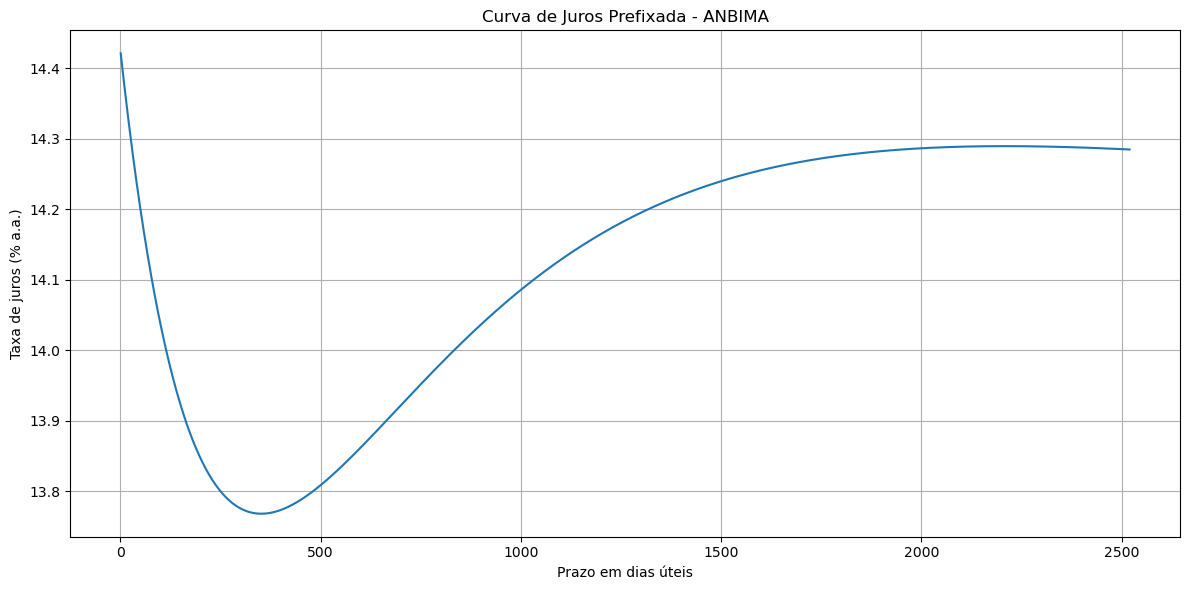

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    curva_juros["dias_uteis_vencimento"],
    curva_juros["r"] * 100
)

plt.xlabel("Prazo em dias úteis")
plt.ylabel("Taxa de juros (% a.a.)")
plt.title("Curva de Juros Prefixada - ANBIMA")

plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import norm
from scipy.optimize import brentq
import numpy as np

# =========================
# VOLATILIDADE IMPLÍCITA - BLACK-SCHOLES
# =========================

def bs_call_price(S, K, T, r, sigma, q=0.0):
    """
    Preço de uma call europeia pelo modelo Black-Scholes.
    S: preço do ativo
    K: strike
    T: tempo até vencimento em anos
    r: taxa livre de risco anual em decimal
    sigma: volatilidade anual em decimal
    q: dividend yield anual em decimal
    """

    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan

    d1 = (
        np.log(S / K) + (r - q + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call = (
        S * np.exp(-q * T) * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    return call


def implied_vol_call(preco_mercado, S, K, T, r, q=0.0):
    """
    Calcula a volatilidade implícita de uma call por busca numérica.
    """

    if any(pd.isna(x) for x in [preco_mercado, S, K, T, r]):
        return np.nan

    if preco_mercado <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    # Limites teóricos aproximados da call
    lower_bound = max(0, S * np.exp(-q * T) - K * np.exp(-r * T))
    upper_bound = S * np.exp(-q * T)

    if preco_mercado < lower_bound or preco_mercado > upper_bound:
        return np.nan

    try:
        return brentq(
            lambda sigma: bs_call_price(S, K, T, r, sigma, q) - preco_mercado,
            1e-6,
            5.0
        )
    except ValueError:
        return np.nan


ATIVO["iv"] = ATIVO.apply(
    lambda row: implied_vol_call(
        preco_mercado=row["preco"],
        S=row["S0"],
        K=row["strike"],
        T=row["T"],
        r=row["r"],
        q=0.0
    ),
    axis=1
)

ATIVO["iv_%"] = ATIVO["iv"] * 100

ATIVO_IV = ATIVO.dropna(subset=["iv"]).copy()

ATIVO_IV[
    [
        "ativo",
        "vencimento",
        "S0",
        "strike",
        "preco",
        "dias_uteis_vencimento",
        "T",
        "r",
        "iv",
        "iv_%"
    ]
].sort_values(["vencimento", "strike"])

,ativo,vencimento,S0,strike,preco,dias_uteis_vencimento,T,r,iv,iv_%
0,PETRE310W5,2026-05-29,44.48,30.46,14.72,4,0.015873,0.144058,2.498212,249.821239
1,PETRE350W5,2026-05-29,44.48,34.46,10.45,4,0.015873,0.144058,1.572103,157.210265
11,PETRE407W5,2026-05-29,44.48,40.21,5.36,4,0.015873,0.144058,1.235592,123.559196
10,PETRE404W5,2026-05-29,44.48,40.46,4.17,4,0.015873,0.144058,0.477667,47.766693
13,PETRE417W5,2026-05-29,44.48,41.21,3.77,4,0.015873,0.144058,0.714827,71.482651
...,...,...,...,...,...,...,...,...,...,...
1104,PETRE507,2027-05-21,44.48,50.71,4.93,259,1.027778,0.137943,0.262859,26.285933
1105,PETRE547,2027-05-21,44.48,54.71,4.02,259,1.027778,0.137943,0.290831,29.083121
1106,PETRE567,2027-05-21,44.48,56.71,3.38,259,1.027778,0.137943,0.287386,28.738560
1107,PETRE587,2027-05-21,44.48,58.71,3.69,259,1.027778,0.137943,0.334379,33.437880
